In [ ]:
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "tools" / "tools.py").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing tools/tools.py")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import scipy
import seaborn as sns
import sklearn
import pysindy as ps
from sklearn.linear_model import Lasso
from tools.tools import (
    get_positive_contributions,
    compute_entropy,
    print_equations,
    compute_transition_covariances,
    fit_data_koopman_operator,
    whiten_operator_matrix,
)
from data_generators.data_func import plot_clustered_kuramoto, generate_kuramoto_cluster_data_sin_cos
import warnings
from sklearn.exceptions import ConvergenceWarning

# 仅忽略收敛警告
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pipline操作流程：

1.生成数据：a 单起始点时间序列；b 多起始点时间序列

可选步骤：时间序列降采样

2.选择合适的library做观测

3.选择合适的optimizer做拟合：a 离散的迭代方程；b 连续的微分方程

4.计算score，多步预测效果看一下

5.提取系数矩阵，进行svd分解，得到奇异值谱和左奇异向量

6.观察奇异值谱截断，计算因果涌现程度，绘制多尺度contribution，计算EC

7.根据奇异向量和谱截断，输出粗粒化函数表达式

8.绘制宏观演化的时间序列，给出宏观动力学方程

可选的分析案例：

1.SIR：原始的SIR动力学；带观测噪音的四维微观数据

2.kuramoto模型

3.洛伦兹动力学

4.耦合Rulkov映射

# 数据生成

In [ ]:
N=10
n_clusters=2  # 团数
K_intra=5
K_inter=0.11
noise=0
dt=0.01

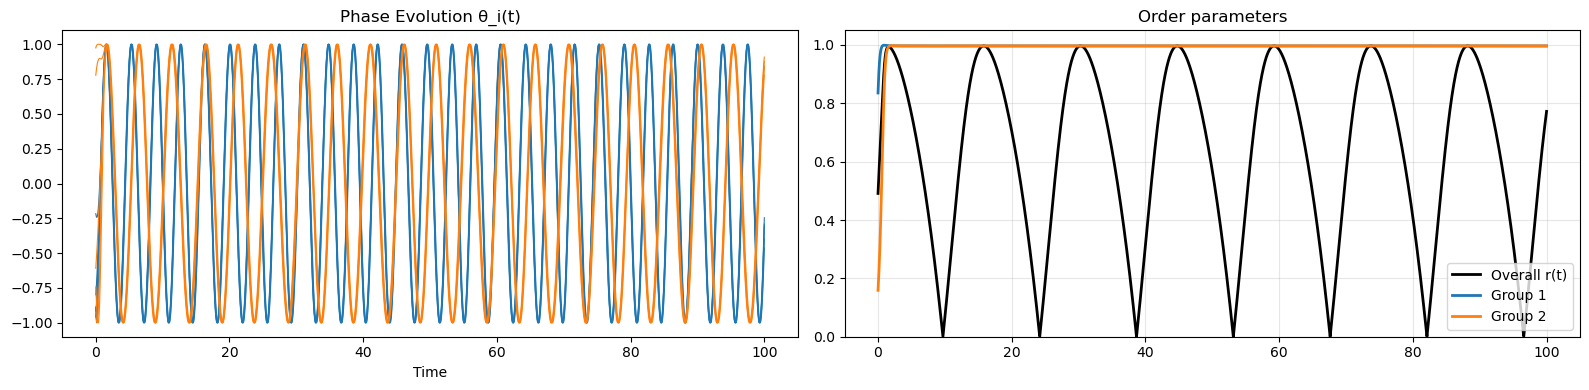

In [ ]:
# 单时间序列采样
x_train, theta_hist, t_train, K_matrix = plot_clustered_kuramoto(
    N=N,          # 振子数
    n_clusters=n_clusters,  # 团数
    K_intra=K_intra,   # 团内耦合
    K_inter=K_inter,   # 团间耦合
    noise=noise,
    T=100,
    random_seed1=0, random_seed2=0,
    dt=dt
)

x_data = x_train[1000:,:]


# 选择library

In [ ]:
# 候选的观测函数
ide = ps.IdentityLibrary()
fourier = ps.FourierLibrary(n_frequencies=1)
ode_lib = ps.PolynomialLibrary(degree=2,include_bias=False)
library_functions = [
    lambda x: 1,
    lambda x: x,
    lambda x: np.sin(x),
    lambda x: np.cos(x),
]
custom_library = ps.CustomLibrary(library_functions=library_functions)

# 选定观测函数
library = ide + fourier

# 进行lift
library.fit(x_data)
x_data_lift = library.transform(x_data)
names = library.get_feature_names()

# 单时间序列
print(x_data_lift.shape)
# 多时间序列
#print(x_data_lift[0].shape)
# 检查观测函数变量名
print(names)

(9000, 60)
['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'sin(1 x0)', 'cos(1 x0)', 'sin(1 x1)', 'cos(1 x1)', 'sin(1 x2)', 'cos(1 x2)', 'sin(1 x3)', 'cos(1 x3)', 'sin(1 x4)', 'cos(1 x4)', 'sin(1 x5)', 'cos(1 x5)', 'sin(1 x6)', 'cos(1 x6)', 'sin(1 x7)', 'cos(1 x7)', 'sin(1 x8)', 'cos(1 x8)', 'sin(1 x9)', 'cos(1 x9)', 'sin(1 x10)', 'cos(1 x10)', 'sin(1 x11)', 'cos(1 x11)', 'sin(1 x12)', 'cos(1 x12)', 'sin(1 x13)', 'cos(1 x13)', 'sin(1 x14)', 'cos(1 x14)', 'sin(1 x15)', 'cos(1 x15)', 'sin(1 x16)', 'cos(1 x16)', 'sin(1 x17)', 'cos(1 x17)', 'sin(1 x18)', 'cos(1 x18)', 'sin(1 x19)', 'cos(1 x19)']


配对样本数: 8999
C00 shape: (60, 60), C01 shape: (60, 60), C11 shape: (60, 60)
C00 condition number: 5.5659e+16
C11 condition number: 7.4963e+16
min eig(C00): -6.1723e-15
min eig(C11): -6.2916e-15


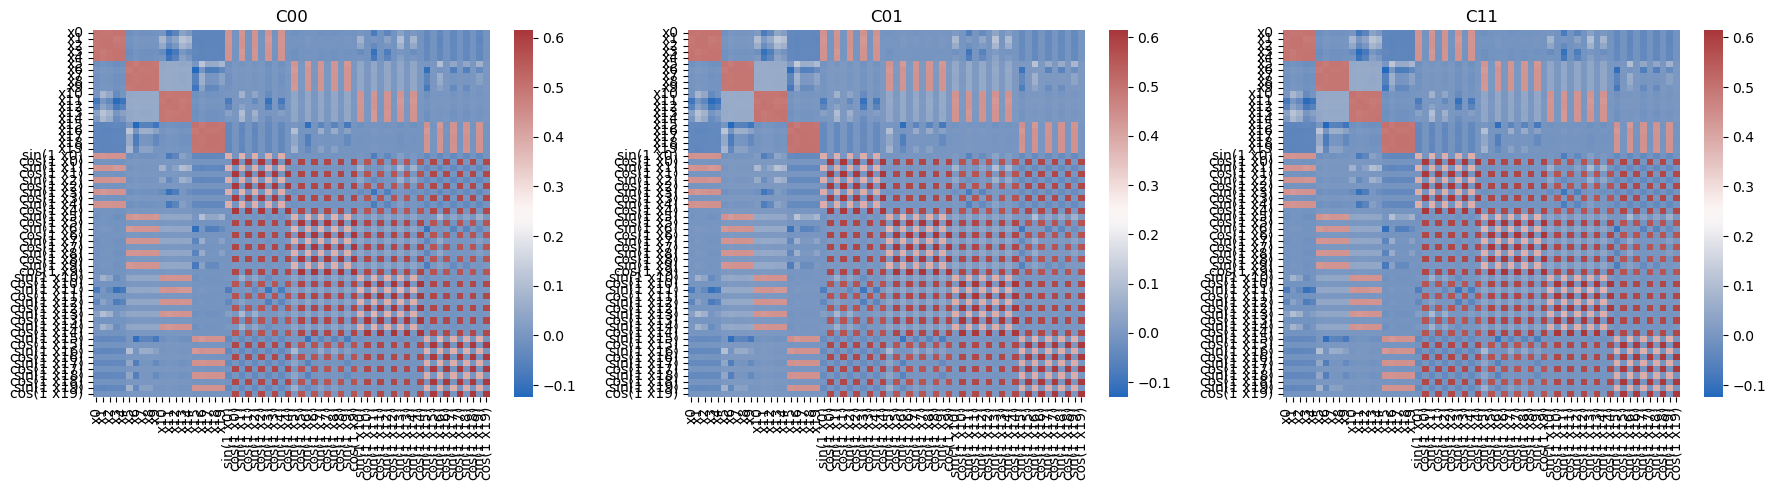

In [ ]:
# 用一步配对样本估计 C00, C01, C11，这才是白化 Koopman 矩阵对应的统计量
transition_stats = compute_transition_covariances([x_data_lift], weights="uniform")
C00 = transition_stats["C00"]
C01 = transition_stats["C01"]
C11 = transition_stats["C11"]

print(f"配对样本数: {transition_stats['X'].shape[0]}")
print(f"C00 shape: {C00.shape}, C01 shape: {C01.shape}, C11 shape: {C11.shape}")
print(f"C00 condition number: {np.linalg.cond(C00):.4e}")
print(f"C11 condition number: {np.linalg.cond(C11):.4e}")
print(f"min eig(C00): {np.min(np.linalg.eigvalsh(0.5 * (C00 + C00.T))):.4e}")
print(f"min eig(C11): {np.min(np.linalg.eigvalsh(0.5 * (C11 + C11.T))):.4e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title in zip(axes, [C00, C01, C11], ["C00", "C01", "C11"]):
    sns.heatmap(mat, ax=ax, cmap="vlag", xticklabels=names, yticklabels=names)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# 进行拟合

In [ ]:
x_data_lift.shape

(9000, 60)

In [ ]:
# 离散的迭代方程 or 连续的微分方程
discrete_time = False

# 候选拟合器
sr3_optimizer = ps.SR3(reg_weight_lam=0.2, regularizer="l2")
lasso_optimizer = Lasso(alpha=0.005, max_iter=20000, fit_intercept=False)
stlsq_optimizer = ps.STLSQ(threshold=0.01, alpha=0.9, verbose=True)

optimizer = lasso_optimizer

# 这里 x_data_lift 已经手动 lift，所以拟合阶段用 IdentityLibrary
model = ps.SINDy(feature_library=ide, optimizer=optimizer, discrete_time=discrete_time)
model.fit(x_data_lift, t=dt, feature_names=names)
model.print()


(x0)' = 0.005 x5 + 0.008 x6 + 0.003 x7 + -1.667 x10 + -0.001 x11 + -0.013 x12 + -0.017 x13
(x1)' = 0.017 x5 + -1.699 x11
(x2)' = 0.009 x5 + 0.007 x7 + -0.725 x10 + -0.980 x11
(x3)' = 0.016 x9 + -0.048 x10 + -1.651 x13
(x4)' = 0.010 x7 + 0.002 x8 + 0.004 x9 + -1.379 x10 + -0.320 x13
(x5)' = 0.018 x1 + -1.256 x15 + -0.002 x17
(x6)' = 0.019 x3 + -1.258 x16
(x7)' = 0.012 x0 + 0.001 x1 + 0.006 x2 + -0.726 x15 + -0.540 x16 + -0.001 x17
(x8)' = 0.013 x0 + 0.001 x1 + 0.005 x2 + -0.694 x15 + -0.572 x16 + -0.001 x17
(x9)' = 0.009 x0 + 0.009 x3 + 0.001 x4 + -0.356 x15 + -0.909 x16
(x10)' = 1.698 x0 + 0.010 x15 + 0.007 x16
(x11)' = 1.699 x1 + 0.017 x15
(x12)' = 0.724 x0 + 0.981 x1 + 0.010 x15 + 0.007 x17
(x13)' = 0.051 x0 + 1.648 x3 + 0.016 x19
(x14)' = 1.383 x0 + 0.316 x3 + 0.014 x17 + 0.001 x18 + 0.002 x19
(x15)' = 1.258 x5 + 0.003 x10 + 0.015 x11
(x16)' = 1.258 x6 + 0.019 x13
(x17)' = 0.726 x5 + 0.540 x6 + 0.001 x7 + 0.014 x10 + 0.004 x12
(x18)' = 0.695 x5 + 0.572 x6 + 0.001 x7 + 0.015 x10 + 0.

In [ ]:
# 计算score
model.score(x_data_lift, t=dt)

0.9679013676419935

# 多步预测

In [ ]:
test_idx = 0
init_data = x_data_lift[0, :]
step_pred = 2000

if discrete_time:
    X_data_predicted = model.simulate(init_data, step_pred)
else:
    # 连续系统必须传入真实时间轴，否则时间尺度会错误
    t_pred = np.arange(step_pred) * dt
    X_data_predicted = model.simulate(init_data, t_pred)

X_data_predicted.shape


(2000, 60)

/var/folders/mw/53dhwskj4zq47dtls4lhht4m0000gn/T/ipykernel_75827/2308130201.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


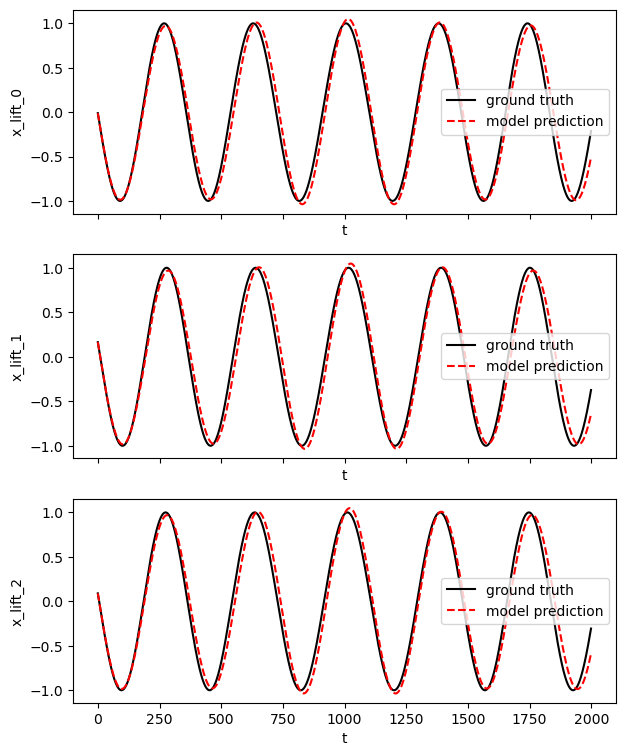

In [ ]:
# 只看部分维度的多步预测
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(7, 9))
for i in range(3):
    axs[i].plot(x_data_lift[:step_pred, i], "k", label="ground truth")
    axs[i].plot(X_data_predicted[:step_pred, i], "r--", label="model prediction")
    axs[i].legend()
    axs[i].set(xlabel="t", ylabel=r"x_lift_{}".format(i))
fig.show()

# svd分解

orientation check: err(A)=5.843e+00, err(A.T)=0.000e+00
||A_step_data - A_step_model||_F = 1.828e+01
max sv(A_step_data)      = 5.613563
max sv(K_bar_model)     = 206.048419
max sv(K_bar empirical) = 1.000000


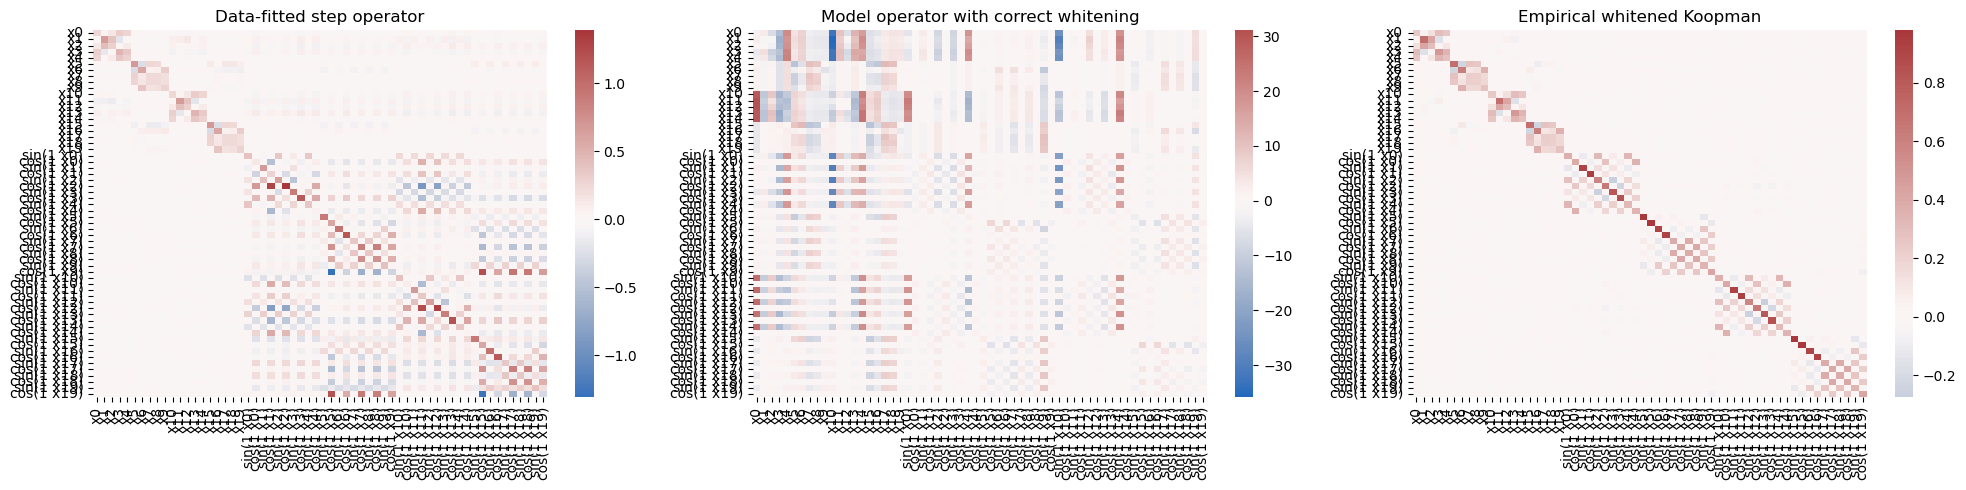

In [ ]:
A_raw = model.coefficients()

# 系数方向一致性检查：选预测误差更小的方向
xdot_model = model.predict(x_data_lift)
err_no_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw.T) / np.linalg.norm(xdot_model)
err_t = np.linalg.norm(xdot_model - x_data_lift @ A_raw) / np.linalg.norm(xdot_model)
A_ct = A_raw if err_t <= err_no_t else A_raw.T
print(f"orientation check: err(A)={err_t:.3e}, err(A.T)={err_no_t:.3e}")

# 连续系统转单步离散算子
A_step_model = scipy.linalg.expm(A_ct ) if not discrete_time else A_ct

koop_fit = fit_data_koopman_operator([x_data_lift], weights="uniform", eps=1e-10, ridge=1e-10)
A_step_data = koop_fit["A"]
K_bar = koop_fit["K_bar"]
C00 = koop_fit["C00"]
C01 = koop_fit["C01"]
C11 = koop_fit["C11"]
C00_inv_sqrt = koop_fit["C00_inv_sqrt"]
C11_inv_sqrt = koop_fit["C11_inv_sqrt"]

model_whitening = whiten_operator_matrix(A_step_model, C00, C11, eps=1e-10)
K_bar_model = model_whitening["A_bar"]

print(f"||A_step_data - A_step_model||_F = {np.linalg.norm(A_step_data - A_step_model):.3e}")
print(f"max sv(A_step_data)      = {np.linalg.svd(A_step_data, compute_uv=False)[0]:.6f}")
print(f"max sv(K_bar_model)     = {np.linalg.svd(K_bar_model, compute_uv=False)[0]:.6f}")
print(f"max sv(K_bar empirical) = {np.linalg.svd(K_bar, compute_uv=False)[0]:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
panels = [
    (A_step_data, "Data-fitted step operator"),
    (K_bar_model, "Model operator with correct whitening"),
    (K_bar, "Empirical whitened Koopman"),
]
for ax, (mat, title) in zip(axes, panels):
    sns.heatmap(mat, ax=ax, xticklabels=names, yticklabels=names, cmap="vlag", center=0)
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

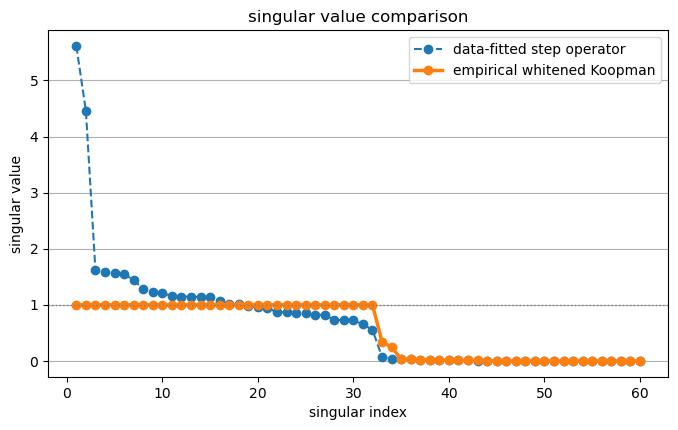

In [ ]:
U, S, Vt = np.linalg.svd(K_bar)
S_raw = np.linalg.svd(A_step_data, compute_uv=False)
S_model = np.linalg.svd(K_bar_model, compute_uv=False)

plt.figure(figsize=(8, 4.5))
idx = np.arange(1, len(S) + 1)
plt.plot(idx, S_raw, "o--", label="data-fitted step operator")
plt.plot(idx, S_model, "s--", label="model + correct whitening")
plt.plot(idx, S, "o-", linewidth=2.5, label="empirical whitened Koopman")
plt.axhline(1.0, color="gray", linestyle=":", linewidth=1)
plt.grid(True, axis='y')
plt.xlabel('singular index')
plt.ylabel('singular value')
plt.title('singular value comparison')
plt.legend()
plt.show()

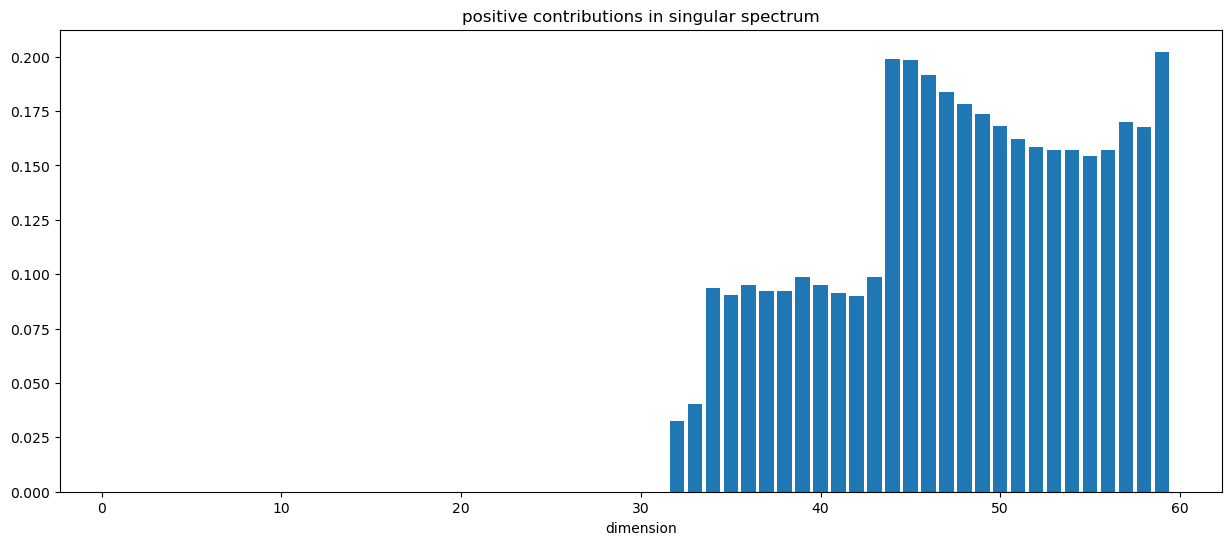

In [ ]:
# 多尺度因果力分布
diff = get_positive_contributions(S)
plt.figure(figsize=(15, 6))
plt.bar(range(1,len(diff)+1), diff) 
plt.xlabel('dimension')
plt.title('positive contributions in singular spectrum')
plt.show()

In [ ]:
# 选取截断
rank = 2
S_macro = S[:rank]
delt_gamma = sum(S_macro) / rank - sum(S) / len(S)
print(delt_gamma)

0.45400785986307823


In [ ]:
# 计算EC
print(compute_entropy(diff))

4.706298145351282


# 输出粗粒化表达式

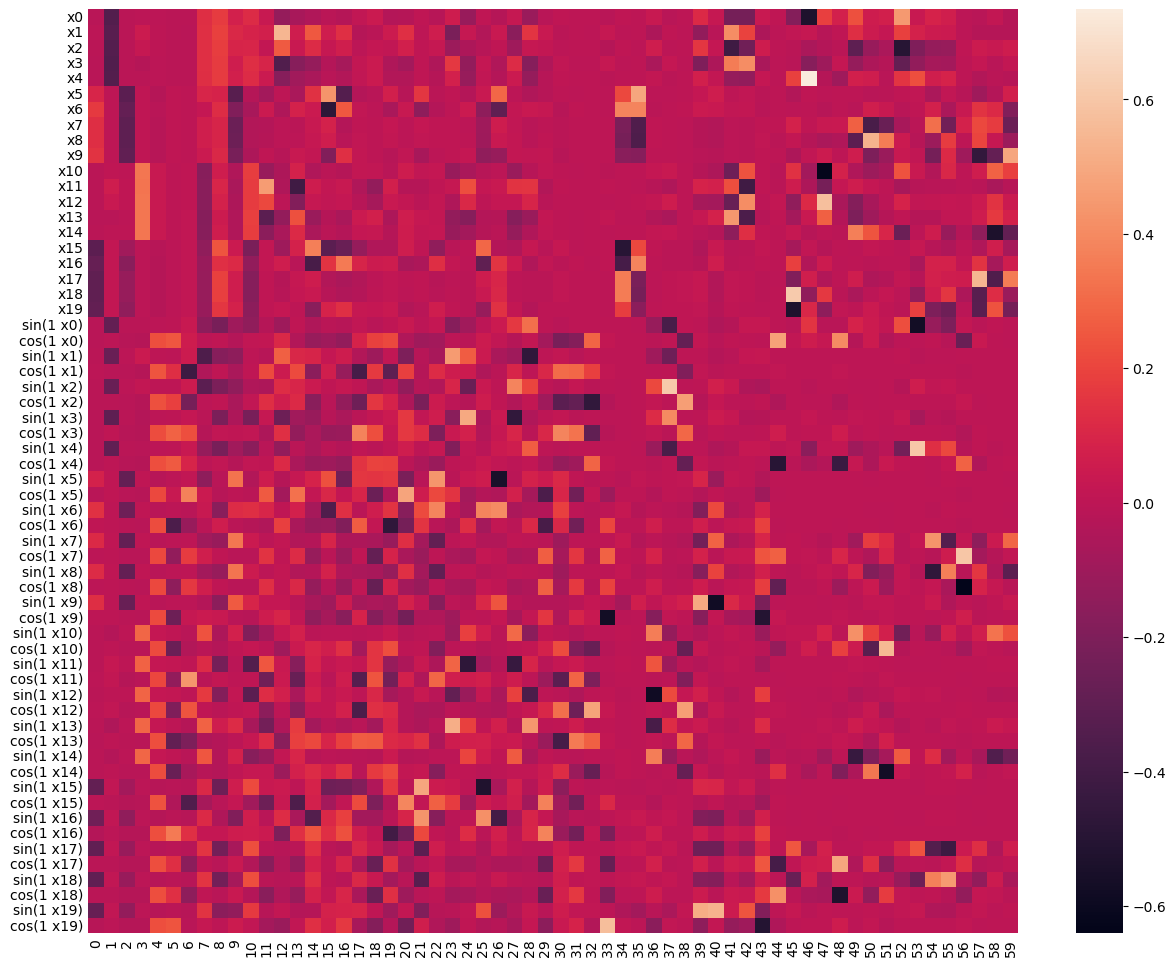

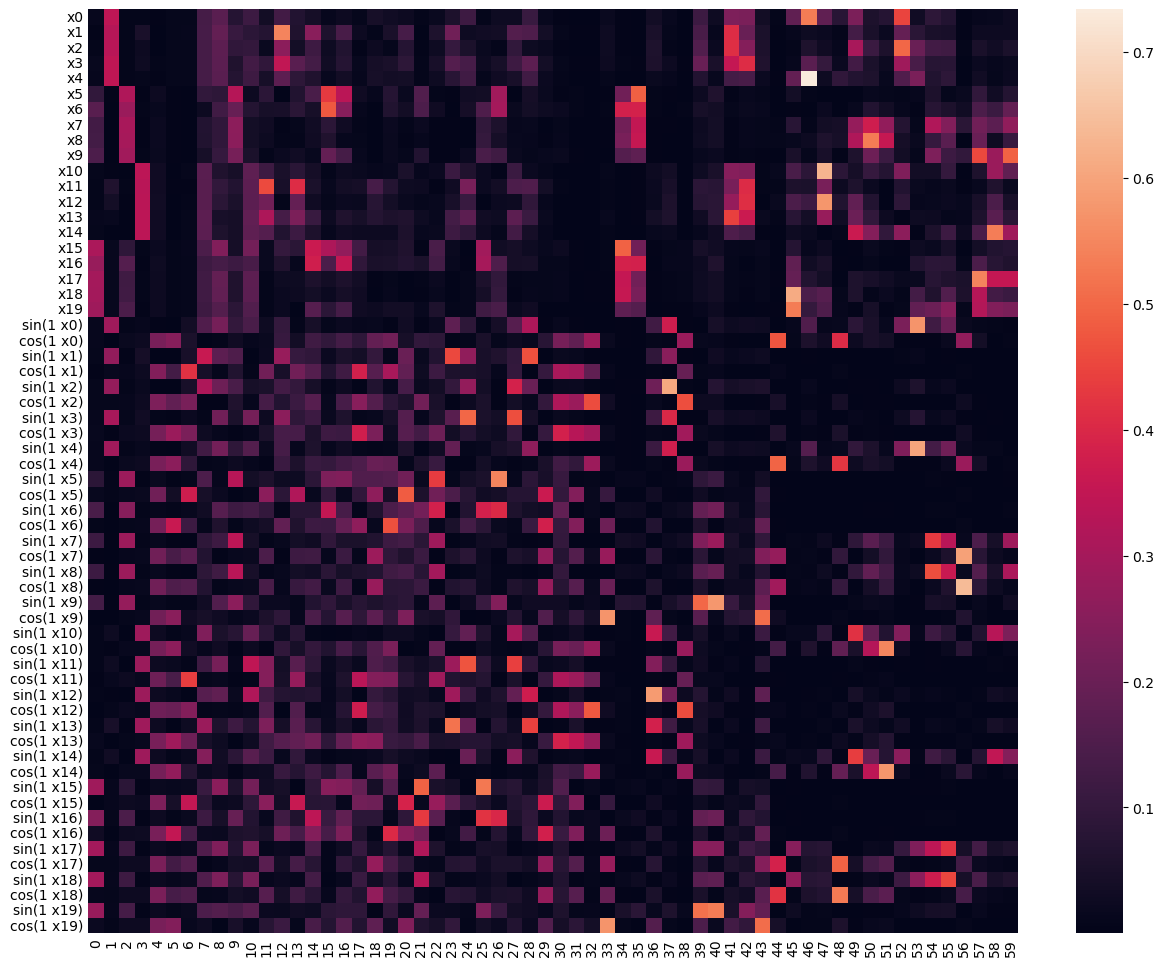

In [ ]:
# 绘制奇异向量
U_abs = np.abs(U)

plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show()


plt.figure(figsize=(15, 12)) 
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(U_abs, yticklabels=names)
plt.xticks(rotation=90)  
plt.yticks(rotation=0)   
plt.show() 

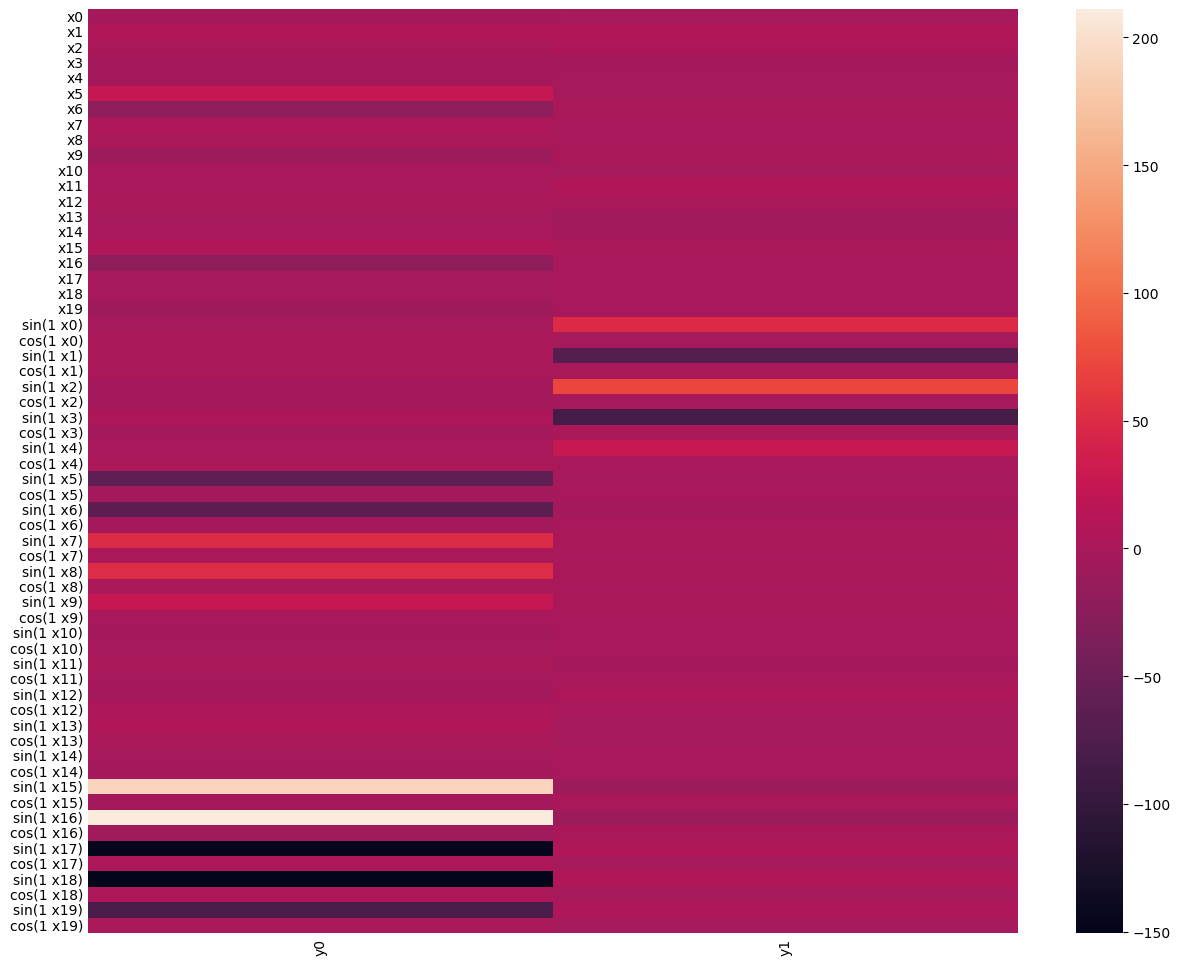

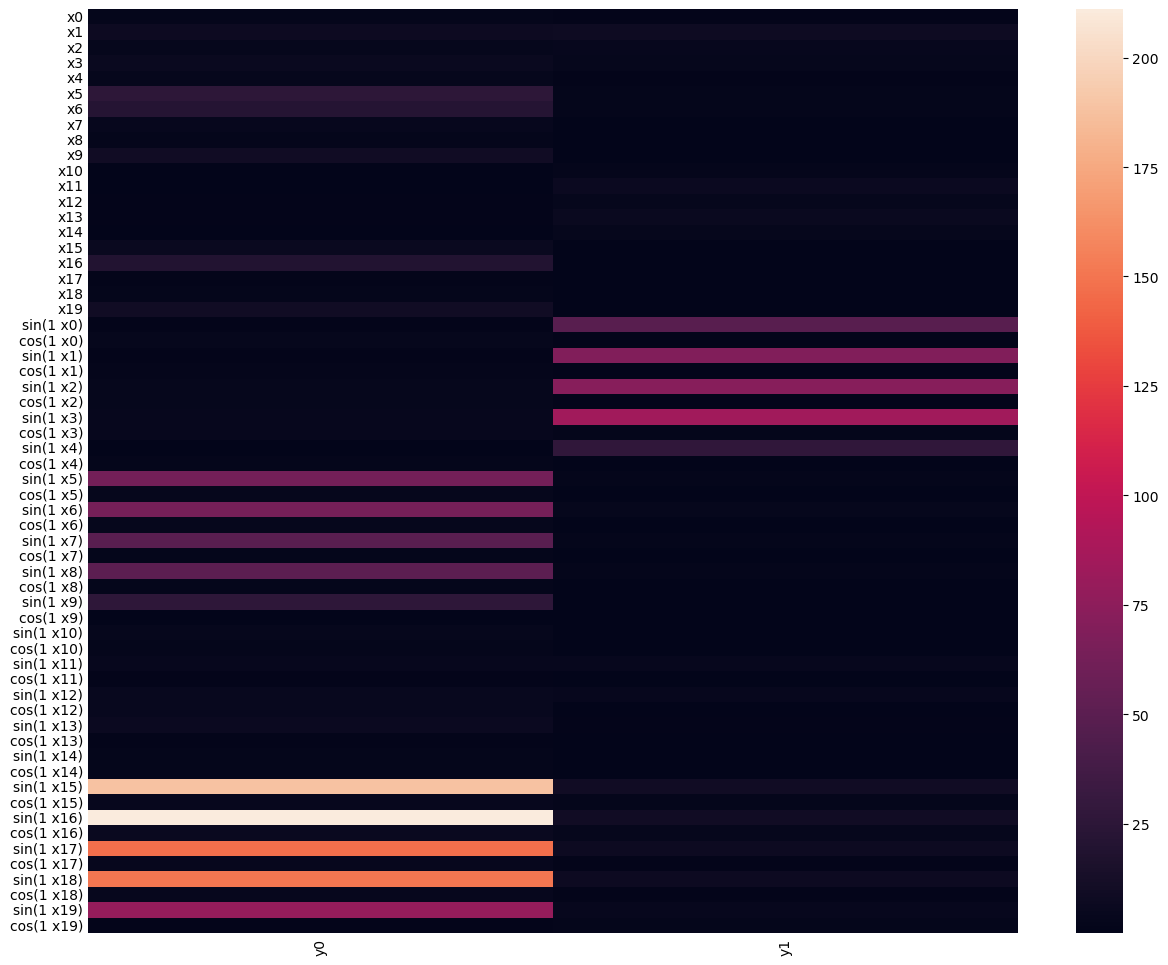

In [ ]:
# 粗粒化函数系数
macro_name = [f'y{i}' for i in range(rank)]
coarse_grain_coff = C00_inv_sqrt @ U[:,:rank]

plt.figure(figsize=(15, 12))
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(coarse_grain_coff, yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

plt.figure(figsize=(15, 12))
plt.tick_params(axis='both', which='both', length=0)
_ = sns.heatmap(np.abs(coarse_grain_coff), yticklabels=names, xticklabels=macro_name)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# 输出粗粒化函数表达式
print_equations(coarse_grain_coff, names, macro_name)

y0 = -2.3124 * x0 + 6.7848 * x1 + 2.7774 * x2 - 4.9664 * x3 - 2.9225 * x4 + 25.5553 * x5 - 21.0212 * x6 + 3.5194 * x7 + 2.3246 * x8 - 9.7490 * x9 + 0.0383 * x10 - 0.1093 * x11 + 0.8486 * x12 - 1.5220 * x13 - 0.2349 * x14 + 5.5321 * x15 - 19.3515 * x16 - 1.2731 * x17 - 1.8501 * x18 - 9.2084 * x19 - 1.2737 * sin(1 x0) + 2.8030 * cos(1 x0) + 1.2044 * sin(1 x1) + 1.8456 * cos(1 x1) - 2.7113 * sin(1 x2) - 2.4850 * cos(1 x2) + 3.8795 * sin(1 x3) - 4.1123 * cos(1 x3) - 0.4461 * sin(1 x4) + 2.4643 * cos(1 x4) - 62.1079 * sin(1 x5) - 2.5865 * cos(1 x5) - 63.1329 * sin(1 x6) - 2.9744 * cos(1 x6) + 49.3806 * sin(1 x7) + 2.4042 * cos(1 x7) + 50.3889 * sin(1 x8) + 2.3468 * cos(1 x8) + 25.7519 * sin(1 x9) + 0.3126 * cos(1 x9) - 3.2633 * sin(1 x10) - 2.0774 * cos(1 x10) + 3.3120 * sin(1 x11) - 1.0548 * cos(1 x11) - 4.9220 * sin(1 x12) + 4.8163 * cos(1 x12) + 6.0358 * sin(1 x13) + 1.2528 * cos(1 x13) - 1.7906 * sin(1 x14) - 2.3359 * cos(1 x14) + 188.7934 * sin(1 x15) - 3.8656 * cos(1 x15) + 211.1087 *

# 描述宏观演化

/var/folders/mw/53dhwskj4zq47dtls4lhht4m0000gn/T/ipykernel_75827/2767867501.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


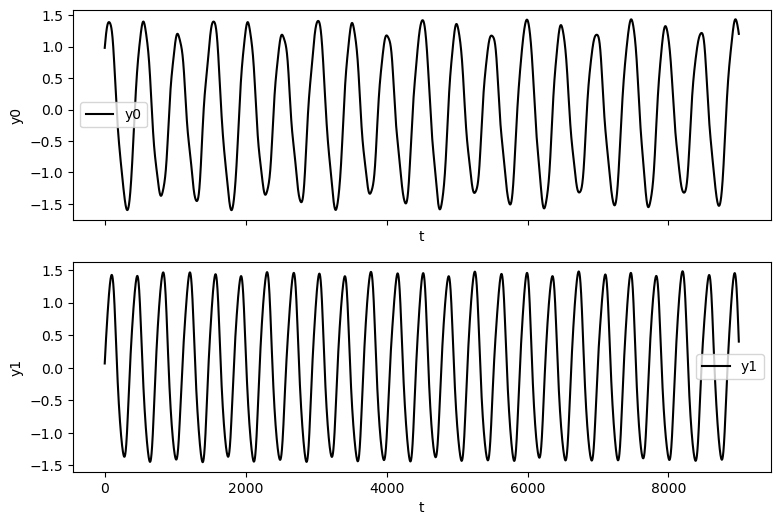

In [ ]:
macro_data = x_data_lift @ coarse_grain_coff
macro_dim = macro_data.shape[1]

fig, axs = plt.subplots(macro_dim, 1, sharex=True, figsize=(9, int(3*macro_dim)))
for i in range(macro_dim):
    axs[i].plot(macro_data[0:, i], "k", label=f"y{i}")
    axs[i].legend()
    axs[i].set(xlabel="t", ylabel=f"y{i}")
fig.show()

In [ ]:
# 给出宏观动力学方程
A_macro = coarse_grain_coff.T @ A_step_data @ coarse_grain_coff
macro_name_k = [i+'[k]' for i in macro_name]
macro_name_next = [i+'[k+1]' for i in macro_name]
print_equations(A_macro, macro_name_k, macro_name_next)


y0[k+1] = 143572.0208 * y0[k] - 6487.6591 * y1[k]
------------------------------
y1[k+1] = -6302.6956 * y0[k] + 19927.8544 * y1[k]
------------------------------


# 频谱分析

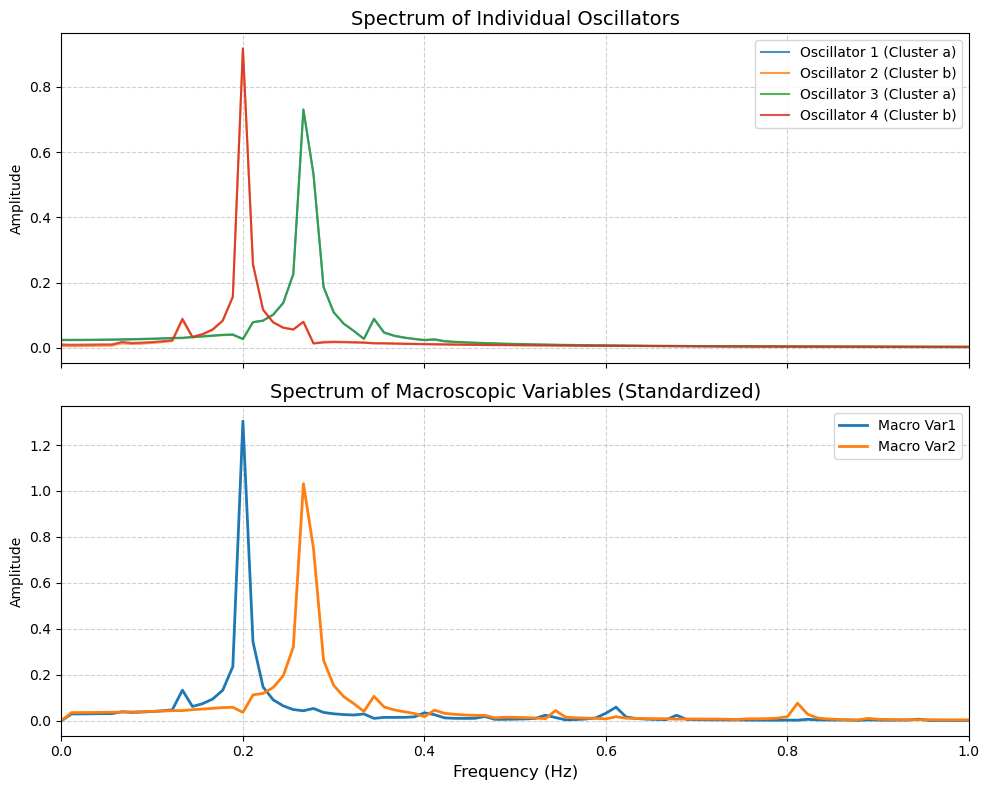

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

n_fft = macro_data.shape[0]
xf = np.fft.fftfreq(n_fft, dt)

micro_signals = [x_data[:, 0], x_data[:, 5], x_data[:, 1], x_data[:, 6]]
micro_labels = [
    'Oscillator 1 (Cluster a)',
    'Oscillator 2 (Cluster b)',
    'Oscillator 3 (Cluster a)',
    'Oscillator 4 (Cluster b)'
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

macro_signals = []
for i in range(macro_dim):
    sig = macro_data[0:, i]
    std = np.std(sig)
    standardized_sig = (sig - np.mean(sig)) / (std + 1e-12)
    macro_signals.append(standardized_sig)
macro_labels = [f'Macro Var{i+1}' for i in range(macro_dim)]

def compute_fft(signal, xf, n_fft):
    yf = fft(signal)
    half_n = n_fft // 2
    return xf[:half_n], np.abs(yf[:half_n]) / n_fft * 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for i, sig in enumerate(micro_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax1.plot(freqs, amps, label=micro_labels[i], color=colors[i], alpha=0.8)

ax1.set_title("Spectrum of Individual Oscillators", fontsize=14)
ax1.set_ylabel("Amplitude")
ax1.legend(loc="upper right")
ax1.grid(True, linestyle='--', alpha=0.6)

for i, sig in enumerate(macro_signals):
    freqs, amps = compute_fft(sig, xf, n_fft)
    ax2.plot(freqs, amps, label=macro_labels[i], color=colors[i % len(colors)], linewidth=2)

ax2.set_title("Spectrum of Macroscopic Variables (Standardized)", fontsize=14)
ax2.set_xlabel("Frequency (Hz)", fontsize=12)
ax2.set_ylabel("Amplitude")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()


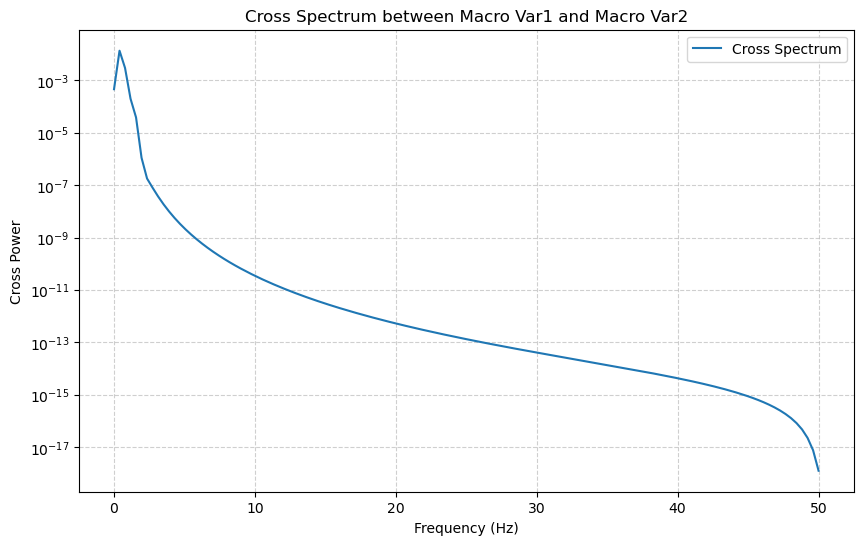

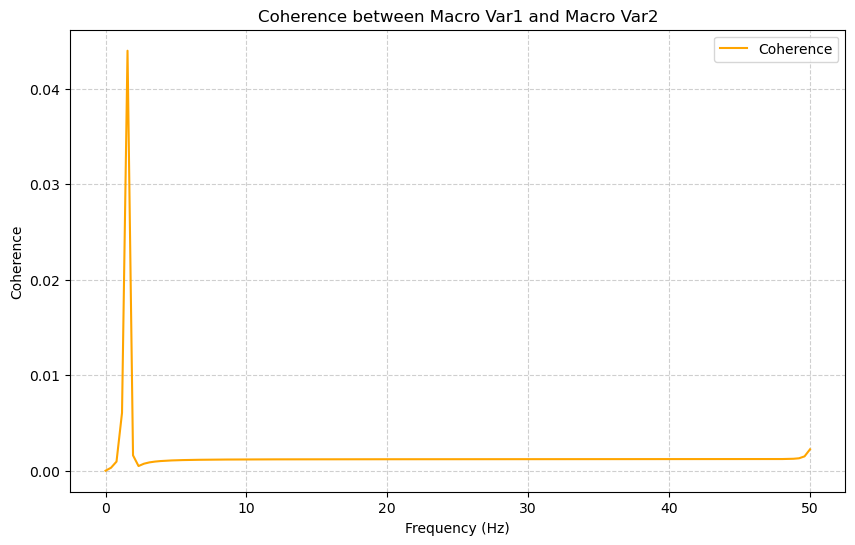

In [ ]:
from scipy.signal import coherence, csd
import matplotlib.pyplot as plt

# 计算交叉频谱和相干性
def compute_cross_spectrum_and_coherence(signal1, signal2, fs):
    # 交叉频谱
    f, Pxy = csd(signal1, signal2, fs=fs, nperseg=256)
    # 相干性
    f_coh, Cxy = coherence(signal1, signal2, fs=fs, nperseg=256)
    return f, Pxy, f_coh, Cxy

# 示例：计算宏观变量之间的交叉频谱和相干性
fs = 1 / dt  # 采样频率
macro_var1 = macro_signals[0]
macro_var2 = macro_signals[1]

f, Pxy, f_coh, Cxy = compute_cross_spectrum_and_coherence(macro_var1, macro_var2, fs)

# 可视化交叉频谱
plt.figure(figsize=(10, 6))
plt.semilogy(f, np.abs(Pxy), label='Cross Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Cross Power')
plt.title('Cross Spectrum between Macro Var1 and Macro Var2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 可视化相干性
plt.figure(figsize=(10, 6))
plt.plot(f_coh, Cxy, label='Coherence', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.title('Coherence between Macro Var1 and Macro Var2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()